In [ ]:
import pickle
import time
from datetime import datetime, timedelta, UTC
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import plotly.express as px
import psycopg
import psycopg_pool
from psycopg import sql

from aare.constants import TIME, TEMP
from aare_influx.field_request import FieldRequest
from aare_influx.remote_existenz_store import RemoteExistenzStore
from aare_timescale.postgres import copy_to_df
from aare_train.preparation import resample
from aare_train.utils import join_many, between

Turns out simulation at 00:00 probably fetches different past data from influx than simulation at 00:15. Need to investigate how much different and whether it has an impact.
For full reproducibility, would need to also archive the fetched target data in the postgres db (instead of only covariates).

Used this patch to get those files

```diff
diff --git a/src/oraku-forecast/main.py b/src/oraku-forecast/main.py
index 57614bd..56be7e4 100644
--- a/src/oraku-forecast/main.py
+++ b/src/oraku-forecast/main.py
@@ -150,6 +150,11 @@ async def forecast_once(
         )

         forecast["run_ts"] = run_ts
+
+        with open(f"./debugging/forecast-{run_ts.isoformat()}{'-sim' if use_cached_external else ''}.pkl",
+                  "wb") as file:
+            import pickle
+            pickle.dump(forecast, file)
     except Exception as e:
         # only catches errors during fetching and forecasting, mostly because fetching has external factors.
         # issues with the database or loading the model will only be visible in the app/container logs.
@@ -175,10 +180,21 @@ async def make_forecast(
     # configure and pull external sources
     sources = SourceRegistry.configure_sources(conn_pool)
     external_data = await load_external_data(sources, run_ts, use_cached_external)
+    with open(f"./debugging/external_data-{run_ts.isoformat()}{'-sim' if use_cached_external else ''}.pkl",
+              "wb") as file:
+        import pickle
+        pickle.dump(external_data, file)

     # compile inference data from internal (influx) and external data
     data = get_inference_data(model_meta["features"], model.extreme_lags, external_data, run_ts)
+    with open(f"./debugging/data-unscaled-{run_ts.isoformat()}{'-sim' if use_cached_external else ''}.pkl",
+              "wb") as file:
+        import pickle
+        pickle.dump(data, file)
     data = scale_inference_data(data, scalers)
+    with open(f"./debugging/data-scaled-{run_ts.isoformat()}{'-sim' if use_cached_external else ''}.pkl", "wb") as file:
+        import pickle
+        pickle.dump(data, file)

     # actually make forecast with loaded model
     return predict(model, data, scalers.get("series") if scalers else None, horizon, num_samples)
```

at ~17:00:03
just forecast

then more or less directly (17:04)
uv run src/oraku-forecast/main.py --simulate-runts 2026-05-03T15:00:12.595844+00:00

then 15min later, at ~17:15
uv run src/oraku-forecast/main.py --simulate-runts 2026-05-03T15:00:12.595844+00:00

then at ~17:34
uv run src/oraku-forecast/main.py --simulate-runts 2026-05-03T15:00:12.595844+00:00

```
│   ├── .
│   ├── actual
│   │   ├── data-scaled-2026-05-03T15:00:12.595844+00:00.pkl [7bd95bacc95b0f272c133c27c990b09cb2b3e85d5957d4c5bfff3a75bd1cd74d]
│   │   ├── data-unscaled-2026-05-03T15:00:12.595844+00:00.pkl [db07afa17d41f59675b569d0394490c3df2672cb5e62f3cf4778454e1694351d]
│   │   ├── external_data-2026-05-03T15:00:12.595844+00:00.pkl [472b36174e3a5188f137963a3c23000b0df121c1b78b7a63adf2fa85775c3c0c]
│   │   ├── forecast-2026-05-03T15:00:12.595844+00:00.pkl [cdce0c47d53869429c867064bbf3e592fdae2f34e160a94c4ced23a8bc9aa11e]
│   │   ├── log.txt [6a73cac4ec71254e2335f039550fa453b21d0b62e42b2d19657730e3cb9aa6b9]
│   ├── output_sim
│   │   ├── 2026-05-03T17:04:10_nowcasting_temp-1.0.parquet [51760f0ebd0611438f18b041954ca2281a75827df8a4f77f86432f1b51e08c06]
│   │   ├── 2026-05-03T17:15:57_nowcasting_temp-1.0.parquet [5a85e3964341d813143751782cebf5807463abfc138de6a9a74b0fb032acf3b9]
│   │   ├── 2026-05-03T17:35:04_nowcasting_temp-1.0.parquet [5a85e3964341d813143751782cebf5807463abfc138de6a9a74b0fb032acf3b9]
│   ├── sim_1704
│   │   ├── data-scaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [7bd95bacc95b0f272c133c27c990b09cb2b3e85d5957d4c5bfff3a75bd1cd74d]
│   │   ├── data-unscaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [db07afa17d41f59675b569d0394490c3df2672cb5e62f3cf4778454e1694351d]
│   │   ├── external_data-2026-05-03T15:00:12.595844+00:00-sim.pkl [d70328b82c594b03b1ddf0e7bdd1b38a68cfda9ac9bbd28b20772b799a98e9d6]
│   │   ├── forecast-2026-05-03T15:00:12.595844+00:00-sim.pkl [cdce0c47d53869429c867064bbf3e592fdae2f34e160a94c4ced23a8bc9aa11e]
│   │   ├── log.txt [561574390f8d90f39da688847e61d8bbe95e7ed608f77a036ac0a5f081b44c36]
│   ├── sim_1715
│   │   ├── data-scaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [abc023fa1857d134ecbe39215a9e2cc2a1117b7a98ad967e8167357416d610b4]
│   │   ├── data-unscaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [cf44488ce237986c7483a752f959286781fece6513d55533a0cf79f65b497957]
│   │   ├── external_data-2026-05-03T15:00:12.595844+00:00-sim.pkl [d70328b82c594b03b1ddf0e7bdd1b38a68cfda9ac9bbd28b20772b799a98e9d6]
│   │   ├── forecast-2026-05-03T15:00:12.595844+00:00-sim.pkl [b5c74f10104dbf922d7a1dd3a9db4f5b1153d5b53d572fbcacd463a8f7184d12]
│   │   ├── log.txt [ebe313eb0eab1ba26e23d3488e195e65590e71b076b133644d14f8a0a30db222]
│   ├── sim-1735
│   │   ├── data-scaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [abc023fa1857d134ecbe39215a9e2cc2a1117b7a98ad967e8167357416d610b4]
│   │   ├── data-unscaled-2026-05-03T15:00:12.595844+00:00-sim.pkl [cf44488ce237986c7483a752f959286781fece6513d55533a0cf79f65b497957]
│   │   ├── external_data-2026-05-03T15:00:12.595844+00:00-sim.pkl [d70328b82c594b03b1ddf0e7bdd1b38a68cfda9ac9bbd28b20772b799a98e9d6]
│   │   ├── forecast-2026-05-03T15:00:12.595844+00:00-sim.pkl [b5c74f10104dbf922d7a1dd3a9db4f5b1153d5b53d572fbcacd463a8f7184d12]
│   │   ├── log.txt [57a1b73580a0e3aa7ecd840240a2986f5eedef8e99b19749e942a7ff28346292]
```

Initial notes:

- External data changes between real and simulation, maybe because of float precision and storage? TODO confirm
- Direct and initial simulation have the same inference data (scaled and unscaled), despite different external data. Ultimately, this leads to the same forecast.
- Simulation 15min later has the same external data as initial simulation, supporting theory that it's about storage/retrieval, not some inherent fluctuation.
- Simulation 15min and 34min later have different inference data than the direct call and initial simulation. The external data is the same, so it's most likely that different data is fetched from influx??
- Logs confirm that influx query is the same every time.

TODO analyze pickles and check differences. It's possible that the influxdb is updated at 00:00:>12 but <00:15:00, but by how much and what's the impact?
TODO test with FIRST features, because it's very possible that the last 10min value hasn't reached influx db at 00:00:12 yet, so the MEAN agg is different, but the FIRST agg wouldn't be!


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 9)

In [ ]:
import logging

logging.basicConfig(level="DEBUG")
logging.getLogger("fsspec").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("dulwich").setLevel(logging.WARNING)

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
exp_dir = Path("../debugging/2026-05-03T15:00:12.595844+00:00")
dir_actual = exp_dir / "actual"
dir_sim_04 = exp_dir / "sim_1704"
dir_sim_15 = exp_dir / "sim_1715"
# dir_sim_35 = exp_dir / "sim_1735"  not needed, identical to 1715

In [ ]:
def load(path: Path):
    if not path.exists():
        ls = list(path.parent.glob(path.name + "*.pkl"))
        if len(ls) != 1:
            raise ValueError("Didn't get exactly 1 thing: " + ", ".join(ls))

        path = ls[0]

    with open(path, "rb") as file:
        return pickle.load(file)

In [ ]:
actual_ext = load(dir_actual / "external_data")
actual_unscaled = load(dir_actual / "data-unscaled")
actual_forecast = load(dir_actual / "forecast")

In [ ]:
sim_04_ext = load(dir_sim_04 / "external_data")
sim_04_unscaled = load(dir_sim_04 / "data-unscaled")
sim_04_forecast = load(dir_sim_04 / "forecast")

In [ ]:
sim_15_ext = load(dir_sim_15 / "external_data")
sim_15_unscaled = load(dir_sim_15 / "data-unscaled")
sim_15_forecast = load(dir_sim_15 / "forecast")

### need to check/analyze:
- external data is different for actual vs (all) simulation, but not parts that are put into data-[un]scaled, so probably flow or something.
- data unscaled (specifically non-external so from influx) is different between 04 and 15 sim.

In [ ]:
actual_ext

In [ ]:
# okay it's not flow..
(actual_ext["bafu_flow"] == sim_04_ext["bafu_flow"]).all().all()

In [ ]:
(actual_ext["meteotest"] == sim_04_ext["meteotest"]).all().all()

In [ ]:
actual_ext["meteotest"]

In [ ]:
# the time is the same for both, so nothing weird there
sim_04_ext["meteotest"]

In [ ]:
# some are perfectly identical, some aren't. seems to depend on the column.
(actual_ext["meteotest"] == sim_04_ext["meteotest"]).sum()

In [ ]:
# however once you tolerate minor fluctuations due to precision loss etc. both are identical.
np.allclose(actual_ext["meteotest"].drop(columns=["_time"]).to_numpy(),
            sim_04_ext["meteotest"].drop(columns=["_time"]).to_numpy())

#### So why is external data different between actual and simulation?

**minor precision differences, probably due to storage and transfer**

### Difference in data from influx between simulations

In [ ]:
# first validate that covariates (coming from external data) aren't any different.
# ps. just now realized again that we don't have any non-linear transformations on water temp
# because that doesn't work autoregressively in darts, ouch that's pretty bad.
sim_04_unscaled

In [ ]:
np.allclose(sim_04_unscaled["future_covariates"].values(), sim_15_unscaled["future_covariates"].values())

In [ ]:
fut_same = (sim_04_unscaled["future_covariates"].to_dataframe() == sim_15_unscaled["future_covariates"].to_dataframe())
fut_same

In [ ]:
# all features are different at just 1h, except for ma3, which is different in 3 hours (makes sense, avg over 3)
fut_same.sum()

In [ ]:
# the three hours that are different are the first 3 (actually just the first (just minutes ago),
# the other 2 are just from ma3 propagating the difference of the first).
_s = fut_same.sum(axis=1)
_s[_s != 5]

In [ ]:
fut_04 = sim_04_unscaled["future_covariates"].to_dataframe()
fut_15 = sim_15_unscaled["future_covariates"].to_dataframe()

In [ ]:
fut_04[between(fut_04, "2026-05-03 15:00:00", "2026-05-03 17:00:01")]

In [ ]:
fut_15[between(fut_15, "2026-05-03 15:00:00", "2026-05-03 17:00:01")]

#### there you have it folks, that first hour is slightly different.

This was made with hourly mean values, both in the model training and the service.
The influxdb sets the label to the right so it seems that between the first run at 17:04 and the second at 17:15,
the data between 16:00 and 17:00 changed slightly (e.g. a datapoint was added) and thus the mean was different.
Next we should test if this can also happen with the FIRST feature modeling.


In [ ]:
# interestingly it's actually the air temperature taken from influx that is causing the difference
# because the target series (water temp) is the same on sim04 and sim15.
np.allclose(sim_04_unscaled["series"].values(), sim_15_unscaled["series"].values())

I also tried to find the exact time things become different (e.g. when tt is updated in influx after the fact).
It seems to be at minute ~8. If it were sooner, e.g. at minute 1, I think it would've made sense to wait a bit with doing the forecasts
(as opposed to exactly at 00), but at 08 I don't think this makes sense.

The takeaway should be

- currently I cannot accurately reproduce all forecasts because the data in the influxdb is not archived/snapshotted with each run
- to compare different models/services on "actual" forecasts (where the covariates come from external forecasting services, not measurement stores),
  I should also simulate all the runs I want to compare instead of using the ones from the prod db, because those used slightly different covariates.

```
│   ├── .
│   ├── 03
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
│   ├── 04
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
│   ├── 05
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
│   ├── 06
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
│   ├── 07
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
│   ├── 08
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 09
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 10
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 11
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 12
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 13
│   ├── 14
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [e6e7966808e251324ee8b4eadcbc9b5bb82d0fb1f302693a7e4fd0c9b4526b63]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [40640fd9cc1ab18823808e8b508d7c64ddcb60a2508f69d07cd1ac06aaf1d343]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [b377e921ff60e62bca3794be2420e2ee2036b767d79e4a022bf68ff94826622d]
│   ├── 15
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [ebbae54ccd070e6a80a20618ef92db741bd04d3b809a909aa2c8ff0d01f5d471]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00-sim.pkl [eef4b363753aeb385428788e549c84ac1a4f5ef3db58ae1156fce4aab2912cdb]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00-sim.pkl [f638d9ff571e4b9a5b16af5cd8d032202a882081ae06a51b30b081acf678b460]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00-sim.pkl [975034b997f15dc162bd196e48332c76296fae4812554093f89738e49d085e03]
│   ├── actual
│   │   ├── data-scaled-2026-05-09T06:00:36.532805+00:00.pkl [ea9d7b38a7a81b1fb02d2a6fb8c7d10244bbdab0320a9c94fd606abb3eef4103]
│   │   ├── data-unscaled-2026-05-09T06:00:36.532805+00:00.pkl [09ae644a7a55d14ff7fdf053532e2bd36042dfed5ed5e66f3044b435106a5824]
│   │   ├── external_data-2026-05-09T06:00:36.532805+00:00.pkl [aefca1b7277bc2eb122ac405db39c76668937e51988d2a479183d08ed729c71b]
│   │   ├── forecast-2026-05-09T06:00:36.532805+00:00.pkl [2b7adfd0c06f529a38976bbd439c906365dd5d39b0893297b64034410893a0cd]
```

The same analysis once more but with the previously deployed model nowcasting_temp-1.0 and MEAN features, maybe there's a difference?

Here it changed at minute 5, ~~but otherwise no notable difference so it seems like MEAN and FIRST features behave the same in respect to
changing covariate data between 00 and 05~~. This could mean that the air temperature is only updated at 05 (or sometimes even later) and
that there isn't a measurement point at 00, which would mean it gets interpolated hourly! So the value at 01:00 is not measured but
interpolated from 00:00 (measured) and 02:00, which is definitely a really bad thing for the model!

**SO YOU SHOULD EVALUATE THE DIFFERENCE BETWEEN THE REAL FORECASTS AND THE SIMULATED ONES IN MORE DETAIL!**

Oh no and it gets worse. This is only the case with FIRST features, because MEAN features will always have a datapoint at 01:00 in this case,
it's just the mean of 10:00-10:50 (label is right), but for FIRST, there really is no datapoint because the data at 01:00 would need to be 01:00 or later
and as we can see further below, tt is updated 5min later than the data point so 01:00 first appears at 01:05.
**So comparing real forecasts with simulated ones won't anticipate how bad the forecasts in the first hours will be when switching to FIRST features,
since all real forecasts we have so far are using MEAN features!**.
Probably best to deploy quickly and do a short comparison after.


```
│   ├── .
│   ├── 00
│   │   ├── 2026-05-13T20:00:25_nowcasting_temp-1.0.parquet [11e9a067c0d08946106c21529d302bac9ce2265ba173f376497f6f158f1a2c35]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── 01
│   │   ├── 2026-05-13T20:01:06_nowcasting_temp-1.0.parquet [11e9a067c0d08946106c21529d302bac9ce2265ba173f376497f6f158f1a2c35]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── 02
│   │   ├── 2026-05-13T20:02:06_nowcasting_temp-1.0.parquet [11e9a067c0d08946106c21529d302bac9ce2265ba173f376497f6f158f1a2c35]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── 03
│   │   ├── 2026-05-13T20:03:06_nowcasting_temp-1.0.parquet [11e9a067c0d08946106c21529d302bac9ce2265ba173f376497f6f158f1a2c35]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── 04
│   │   ├── 2026-05-13T20:04:06_nowcasting_temp-1.0.parquet [11e9a067c0d08946106c21529d302bac9ce2265ba173f376497f6f158f1a2c35]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── 05
│   │   ├── 2026-05-13T20:05:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 06
│   │   ├── 2026-05-13T20:06:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 07
│   │   ├── 2026-05-13T20:07:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 08
│   │   ├── 2026-05-13T20:08:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 09
│   │   ├── 2026-05-13T20:09:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 10
│   │   ├── 2026-05-13T20:10:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 11
│   │   ├── 2026-05-13T20:11:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 12
│   │   ├── 2026-05-13T20:12:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 13
│   │   ├── 2026-05-13T20:13:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 14
│   │   ├── 2026-05-13T20:14:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 15
│   │   ├── 2026-05-13T20:15:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 16
│   │   ├── 2026-05-13T20:16:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 17
│   │   ├── 2026-05-13T20:17:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 18
│   │   ├── 2026-05-13T20:18:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 19
│   │   ├── 2026-05-13T20:19:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 20
│   │   ├── 2026-05-13T20:20:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── 21
│   │   ├── 2026-05-13T20:21:06_nowcasting_temp-1.0.parquet [48895cccb67cfac4a1af67707c53da6a39f5a301af1114b13314c87b021470e2]
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [c9b0f0550f78aea5eb80b5345a87630630659eeaa8d31befa5431fe29b24d08f]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00-sim.pkl [9047d9f070f84fd644bb1d54706ba413f5fb9b9e310763c22a73b765e2cfa660]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00-sim.pkl [c77191136fdf43bcbae6d11b6a7d0bb6ebc4a65791ae0061682e6b8a8a47ea9b]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00-sim.pkl [ef56ad9058a8162192e4b910c0a085ae1fe7cd61c5bffca8d0ef83a83d1271ff]
│   ├── actual_00
│   │   ├── data-scaled-2026-05-13T18:00:06.702100+00:00.pkl [aa0240fafad71d1ddc65cbde5b84c9dd65044f68a5565e78c3b84555ff999c97]
│   │   ├── data-unscaled-2026-05-13T18:00:06.702100+00:00.pkl [ec266a760f1cf9995d95cbdb34a15a65a9cd1fd4a54482fcd7c7da26f2546765]
│   │   ├── external_data-2026-05-13T18:00:06.702100+00:00.pkl [3a30acaf33abbb53c4c12234372cd5fb0a6d77dbd7a06725439ae757bcbe0db2]
│   │   ├── forecast-2026-05-13T18:00:06.702100+00:00.pkl [68a3e7d444373429f78558ad5079d017e1a1429e8925a3183c6663cc7bde1979]
│   ├── actual_55
│   │   ├── data-scaled-2026-05-13T17:55:06.138779+00:00.pkl [c32a74ab605f8850707cb62eeb2b3b6609ec882fada56268739b5cd1223acfbd]
│   │   ├── data-unscaled-2026-05-13T17:55:06.138779+00:00.pkl [2b32942f4b701fcac7089c6f21e08e1c3cbcc873bd34b75e856fcb9ab0b77736]
│   │   ├── external_data-2026-05-13T17:55:06.138779+00:00.pkl [3a30acaf33abbb53c4c12234372cd5fb0a6d77dbd7a06725439ae757bcbe0db2]
│   │   ├── forecast-2026-05-13T17:55:06.138779+00:00.pkl [16e1272f056136b2ca3a5498578c08d73b829bc2c52126aed09b928b14dae341]
```


Using the following code to see when measurements are updated exactly:

```python
from datetime import datetime, UTC, timedelta
import time
from pathlib import Path
from aare_influx.remote_existenz_store import RemoteExistenzStore

client = RemoteExistenzStore()
dir = Path("../debugging/tt_change")
dir.mkdir(exist_ok=True)
start = datetime.now(UTC) - timedelta(hours=1)
for i in range(200):
    now = datetime.now(UTC)
    tt_meas = client.query_raw(f"""
    from(bucket: "existenzApi")
      |> range(start: {start.isoformat()}, stop: now())
      |> filter(fn: (r) => r["_measurement"] == "smn")
      |> filter(fn: (r) => r["_field"] == "tt")
      |> filter(fn: (r) => r["loc"] == "BER")
      |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
      |> drop(columns: ["_start", "result", "_stop", "table", "_measurement", "loc"])
    """)
    tt_meas.to_csv(dir / f"tt_BER_{now.isoformat()}.csv")
    time.sleep(30)
```

Let it run once for smn/tt@BER and once for hydro/temperature@2135. Results:

- smn/tt measurements are **15min behind** (!) (point at 00:10 is retrievable at 00:25)
- hydro/temperature measurements are **8min behind** (point at 00:10 is retrievable at 00:18)

What does this mean:

For MEAN features (semi-confirmed, lines up with times we saw):

- At 01:00, hydro data will already have all data points (00:00-00:50), so it won't change throughout the hour
- At 01:00, smn data will be missing one point, so it takes the average of 00:00-00:40. It will change once at ~01:08 when the data point at 00:50 is available.

For FIRST features (hypothesis, cannot fully confirm yet):

- At 01:00, hydro and smn data will both be missing since there is no datapoint >= 01:00. It will interpolate from 00:00 (measured) and (02:00) forecasted.
- At 01:10, hydro data will be complete, since the data point at 01:00 was received at 01:08. Smn data will still be missing and interpolated.
- At 01:15, both will be complete since the first data point of the hour was received on both.

data above only shows change at 05, not at 08 and not at 15. Doesn't make sense to me because at 05, only the datapoint at 00:50 was received, but we don't care about
that when we fetch for 01:00 with label left.
TODO try to confirm this and also check what impact this interpolation has on the result. If it's bad, we should definitely only forecast when all data
is available, e.g. always at minute 15. Once per hour is enough anyway since meteotest doesn't change. More would just be to dampen outages.

I ran the same experiment again using the FIRST features and it confirms the FIRST hypothesis that forecasts change at 08 and 15.



```
│   ├── 05
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [4889c930383e99a9e13cfea404013f8ceef2423a6686db49f5647a2ededda942]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [d780d07d30b7ed4a3a5302a95d78885bd21527f0d4b5c96a29f731f14576866e]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [de4d280bc50a38fdd1ead84ea426b73e5b2dad2fd7ef1d6909a3a1193d5488a2]
│   │   ├── future_cov_raw-2026-05-14T10:05:07.067986.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 06
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [4889c930383e99a9e13cfea404013f8ceef2423a6686db49f5647a2ededda942]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [d780d07d30b7ed4a3a5302a95d78885bd21527f0d4b5c96a29f731f14576866e]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [de4d280bc50a38fdd1ead84ea426b73e5b2dad2fd7ef1d6909a3a1193d5488a2]
│   │   ├── future_cov_raw-2026-05-14T10:06:07.129434.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 07
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [4889c930383e99a9e13cfea404013f8ceef2423a6686db49f5647a2ededda942]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [d780d07d30b7ed4a3a5302a95d78885bd21527f0d4b5c96a29f731f14576866e]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [de4d280bc50a38fdd1ead84ea426b73e5b2dad2fd7ef1d6909a3a1193d5488a2]
│   │   ├── future_cov_raw-2026-05-14T10:07:07.229155.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 08
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:08:06.959574.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 09
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:09:06.962901.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 10
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:10:07.610326.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   ├── 11
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:11:07.194930.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   │   ├── target_raw-2026-05-14T10:11:07.118271.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
│   ├── 12
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:12:06.920148.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   │   ├── target_raw-2026-05-14T10:12:06.839724.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
│   ├── 13
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:13:07.024778.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   │   ├── target_raw-2026-05-14T10:13:06.950832.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
│   ├── 14
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [41f992dec8a6a274463229a7682c233b27345206186757dbe835fe5f04debe47]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [9d1969a5552c50f620fb9cd0c4c8a5ab06d42d22b5a4ca60dd55228733013693]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [2949e3f45e3ce6593f422ae59610ce30e9c3bfb6cdc22e3d7393be4b6dfc6c34]
│   │   ├── future_cov_raw-2026-05-14T10:14:07.135530.csv [90c479c39d7aae70d584286c585dbae6fb2230183e6e5d7a5cc6f0690321bdf0]
│   │   ├── target_raw-2026-05-14T10:14:07.062498.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
│   ├── 15
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [96a3b70ebf35ca7691c8fecfde06374a36876106531db70d62a7b81c0119b06b]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [0c80a2571bee098788def87d0d2b1de99c977d08eb4acd3ae75d2e460d8d7146]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [91bc13a21c63537140670477e2bcdc4a9fc2c2b152704ec7d8a6652230c60abe]
│   │   ├── future_cov_raw-2026-05-14T10:15:07.109904.csv [dcee220a8b8884e5657f7b351f7e282efa4e19758b25c774481739bc339d7635]
│   │   ├── target_raw-2026-05-14T10:15:07.026393.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
│   ├── 16
│   │   ├── data-scaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [96a3b70ebf35ca7691c8fecfde06374a36876106531db70d62a7b81c0119b06b]
│   │   ├── data-unscaled-2026-05-14T08:00:06.557486+00:00-sim.pkl [0c80a2571bee098788def87d0d2b1de99c977d08eb4acd3ae75d2e460d8d7146]
│   │   ├── external_data-2026-05-14T08:00:06.557486+00:00-sim.pkl [5ab4d737b02f153d09791ce43dc3c13ab10343d7e416fce079bc1613aeef1c33]
│   │   ├── forecast-2026-05-14T08:00:06.557486+00:00-sim.pkl [91bc13a21c63537140670477e2bcdc4a9fc2c2b152704ec7d8a6652230c60abe]
│   │   ├── future_cov_raw-2026-05-14T10:16:06.949185.csv [dcee220a8b8884e5657f7b351f7e282efa4e19758b25c774481739bc339d7635]
│   │   ├── target_raw-2026-05-14T10:16:06.875161.csv [b4fed1c109d4eddfcc9c8f65b0d384181c17af05b8e37ffbcae26d9c2a1e376a]
```

I also confirmed that the interpolation can be wildly different from the real value as you can see here.
This means that a forecast before minute 15 likely leads to much less accurate forecasts than those later.
The big question is if those forecasts are still better than the one from the previous hour (so using the forecast made on 00:15 until 01:14,
so from 01:00-01:14, the forecast at 01:00 is ignored and 02:00 is not recalculated yet).

For smn/tt
Run at 08:14
```
22	2026-05-14 04:00:00+00:00	7.3
23	2026-05-14 05:00:00+00:00	7.4
24	2026-05-14 06:00:00+00:00	8.4
25	2026-05-14 07:00:00+00:00	9.3
	missing; interpolated to	8.6
26	2026-05-14 09:00:00+00:00	7.9
27	2026-05-14 10:00:00+00:00	8.3
28	2026-05-14 11:00:00+00:00	8.7
29	2026-05-14 12:00:00+00:00	8.7
30	2026-05-14 13:00:00+00:00	8.9
31	2026-05-14 14:00:00+00:00	9.2
```

Run at 08:15
```
22	2026-05-14 04:00:00+00:00	7.3
23	2026-05-14 05:00:00+00:00	7.4
24	2026-05-14 06:00:00+00:00	8.4
25	2026-05-14 07:00:00+00:00	9.3
26	2026-05-14 08:00:00+00:00	6.2
27	2026-05-14 09:00:00+00:00	7.9
28	2026-05-14 10:00:00+00:00	8.3
29	2026-05-14 11:00:00+00:00	8.7
30	2026-05-14 12:00:00+00:00	8.7
31	2026-05-14 13:00:00+00:00	8.9
32	2026-05-14 14:00:00+00:00	9.2
```

So 08:00 was measured at 6.2°C, but interpolation between measurements and forecasts estimated 8.6°C.
Of course this varies wildly between days, but over 2° difference will likely produce very different forecasts.

The same thing is happening for hydro/temperature, but there is no forecast that will produce much different results
when interpolated. AFAIK it hydro will just be extrapolated which isn't anything crazy

Run at 09:07
```
23	2026-05-14 06:00:00+00:00	11.28
24	2026-05-14 07:00:00+00:00	11.37
25	2026-05-14 08:00:00+00:00	11.63
	missing; extrapolated to	11.89
```

Run at 09:08
```
23	2026-05-14 06:00:00+00:00	11.28
24	2026-05-14 07:00:00+00:00	11.37
25	2026-05-14 08:00:00+00:00	11.63
26	2026-05-14 09:00:00+00:00	11.84
```

So the difference (and therefore impact) is much smaller for hydro/temperature.

I calculated this inter- and extrapolation by hand, so let's confirm that's actually what's happening.
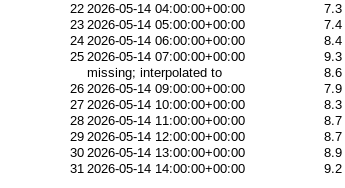

In [ ]:
run_tt_14 = Path("../debugging/finding_tt_change_lr-dev_again/14/")
run_tt_15 = Path("../debugging/finding_tt_change_lr-dev_again/15/")
unscaled_14 = load(run_tt_14 / "data-unscaled")
unscaled_15 = load(run_tt_15 / "data-unscaled")

In [ ]:
unscaled_14["future_covariates"]

In [ ]:
# confirmed! at 08:00 it's interpolated to 8.6
df = unscaled_14["future_covariates"].to_dataframe().reset_index(TIME)
df[TIME] = pd.to_datetime(df[TIME])
df[between(df, "2026-05-14T04:00:00", "2026-05-14T12:00:00")]

In [ ]:
run_hydro_07 = Path("../debugging/finding_temperature_change_lr-dev/07/")
run_hydro_08 = Path("../debugging/finding_temperature_change_lr-dev/08/")
unscaled_07 = load(run_hydro_07 / "data-unscaled")
unscaled_08 = load(run_hydro_08 / "data-unscaled")

In [ ]:
# lol there's no extrapolation, so I guess the forecast just starts an hour earlier?
unscaled_07["series"]

In [ ]:
# yep.. the first hour that is forecasted when running between 09:00 and 09:07 is 09:00, because the last
# target value is at 08:00. Make sense but seems important to know and pretty bad I'm thinking about this so late.
load(run_hydro_07 / "forecast")

In [ ]:
# in this case the water temperature moves really slowly, so the forecast at 09:00 of 11.72°
# is not that far off of the real temperature measured at 09:00, which is 11.84°
# and only becomes available at 09:08.
unscaled_08["series"]

In [ ]:
# just to confirm, at 09:08, the first forecast step is indeed at 10:00 as expected.
load(run_hydro_08 / "forecast")

Conclusion: Only forecast once per hour at minute 15. For a start, also do minute 00, minute 05 and minute 10 and compare those over a few day period.